https://www.kaggle.com/competitions/mortys-time-paradox-aicc-round-3/overview

In [128]:
import pandas as pd
import numpy as np
from sklearn.cluster import SpectralClustering
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [152]:
train = pd.read_csv("/kaggle/input/mortys-time-paradox-aicc-round-3/train.csv")
test = pd.read_csv("/kaggle/input/mortys-time-paradox-aicc-round-3/test.csv")
cand = train.iloc[:, 9:14].values


In [94]:
train

,row_id,x0,x1,x2,x3,x4,x5,x6,x7,cand_0,cand_1,cand_2,cand_3,cand_4
0,0,7.375443,7.594473,9.544929,6.520722,2.372413,10.663466,3.299048,0.106828,1,1,1,0,1
1,1,3.951550,0.546280,1.174609,3.690618,4.712680,6.713291,16.106090,8.096262,1,1,0,1,1
2,2,4.694340,5.452364,6.871558,17.248974,5.753371,10.661893,6.889901,0.849919,1,1,1,1,0
3,3,6.391707,6.135356,6.547818,5.184772,0.858473,9.893235,16.204758,17.211263,1,1,1,0,1
4,4,0.981253,10.000388,4.012973,10.201618,6.817579,0.993900,12.933634,3.246264,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,1.170884,3.796075,4.650353,13.585402,1.563311,9.656252,3.675528,16.455452,1,1,1,1,0
996,996,9.936379,12.127507,14.563744,17.986124,10.936079,5.324378,15.326056,2.088910,1,0,1,1,1
997,997,9.849444,2.809031,9.367284,0.411924,5.023885,6.121839,2.473707,10.258587,1,1,0,1,1
998,998,1.522858,8.842604,10.926543,6.011927,2.264337,0.653945,10.119337,11.433187,0,1,1,1,1


In [95]:
test

,row_id,x0,x1,x2,x3,x4,x5,x6,x7
0,0,4.742837,11.644803,1.123700,4.658670,8.634414,12.837261,9.163153,1.372486
1,1,5.691666,5.162872,6.697662,10.552433,1.764172,4.570268,4.370320,10.325156
2,2,8.118066,1.369183,15.258635,14.401229,4.727289,2.297633,12.644616,13.826028
3,3,5.496239,0.294445,4.244888,8.278670,1.056640,4.377684,11.149974,3.254449
4,4,5.057256,5.841208,9.381881,2.268179,7.282043,5.627389,0.534152,18.159529
...,...,...,...,...,...,...,...,...,...
1495,1495,0.615057,12.461382,9.371403,0.570206,8.026288,0.636259,5.361793,1.518272
1496,1496,5.618275,5.007035,7.411492,8.247335,2.081323,3.974778,3.922015,9.916318
1497,1497,2.268905,12.439977,5.433762,6.723507,4.329656,0.964103,12.871305,3.001460
1498,1498,2.417980,12.586989,4.588404,7.304273,4.722282,0.393880,11.554080,4.149659


In [96]:
train.iloc[:, 1:9]

,x0,x1,x2,x3,x4,x5,x6,x7
0,7.375443,7.594473,9.544929,6.520722,2.372413,10.663466,3.299048,0.106828
1,3.951550,0.546280,1.174609,3.690618,4.712680,6.713291,16.106090,8.096262
2,4.694340,5.452364,6.871558,17.248974,5.753371,10.661893,6.889901,0.849919
3,6.391707,6.135356,6.547818,5.184772,0.858473,9.893235,16.204758,17.211263
4,0.981253,10.000388,4.012973,10.201618,6.817579,0.993900,12.933634,3.246264
...,...,...,...,...,...,...,...,...
995,1.170884,3.796075,4.650353,13.585402,1.563311,9.656252,3.675528,16.455452
996,9.936379,12.127507,14.563744,17.986124,10.936079,5.324378,15.326056,2.088910
997,9.849444,2.809031,9.367284,0.411924,5.023885,6.121839,2.473707,10.258587
998,1.522858,8.842604,10.926543,6.011927,2.264337,0.653945,10.119337,11.433187


In [97]:
array = train.iloc[:, 1:9].to_numpy()
array2 = test.iloc[:, 1:9].to_numpy()
print(array.shape, array2.shape)

(1000, 8) (1500, 8)


In [109]:
final = np.vstack([array, array2])
print(final.shape)
maxs = final.max(axis=0)
T = np.rint(maxs).astype(int)
T = np.maximum(T, 1)

(2500, 8)


In [110]:
empty_set = np.empty((2500, 16))
sin_version = np.sin(final * 2 * np.pi / T)
cosine_version = np.cos(final * 2 * np.pi / T)
print(empty_set.shape)

(2500, 16)


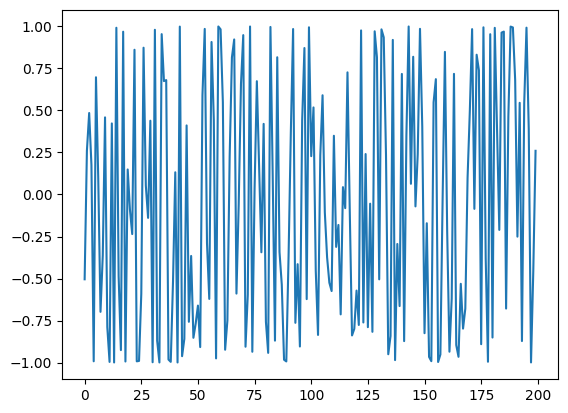

In [143]:
plt.plot(sin_version[:200, 1])
plt.show()

In [142]:
for x in range(8):
    empty_set[:, x*2] = sin_version[:, x]
    empty_set[:, x*2+1] = cosine_version[:, x]
print("Empty set filled shape:", empty_set.shape)

Empty set filled shape: (2500, 16)


In [137]:
tsne = TSNE(n_components = 2, perplexity=50)
pca = PCA(n_components = 2)
empty_set = scaler.fit_transform(empty_set)
emb = tsne.fit_transform(empty_set)

In [138]:
emb.shape

(2500, 2)

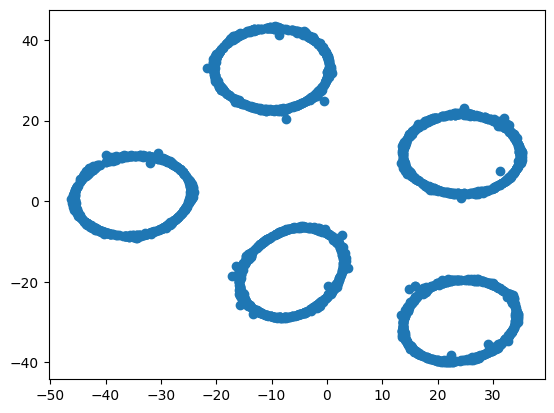

In [141]:
n_train = len(train)

plt.scatter(emb[:, 0], emb[:, 1])

In [144]:
cluster = SpectralClustering(n_clusters = 5)

In [146]:
clusters = cluster.fit_predict(emb)
print(clusters.shape)

(2500,)


In [149]:
clusters[:20]

array([4, 1, 1, 4, 4, 1, 1, 1, 3, 1, 1, 1, 1, 1, 2, 4, 1, 1, 1, 1],
      dtype=int32)

In [150]:
train[:20]

,row_id,x0,x1,x2,x3,x4,x5,x6,x7,cand_0,cand_1,cand_2,cand_3,cand_4
0,0,7.375443,7.594473,9.544929,6.520722,2.372413,10.663466,3.299048,0.106828,1,1,1,0,1
1,1,3.951550,0.546280,1.174609,3.690618,4.712680,6.713291,16.106090,8.096262,1,1,0,1,1
2,2,4.694340,5.452364,6.871558,17.248974,5.753371,10.661893,6.889901,0.849919,1,1,1,1,0
3,3,6.391707,6.135356,6.547818,5.184772,0.858473,9.893235,16.204758,17.211263,1,1,1,0,1
4,4,0.981253,10.000388,4.012973,10.201618,6.817579,0.993900,12.933634,3.246264,1,1,1,1,0
5,5,2.470071,4.902374,6.577072,14.478909,2.855863,9.660060,4.554672,18.467201,1,1,1,1,0
6,6,6.202069,0.200390,0.489865,16.318464,2.026175,4.888316,11.741951,7.545407,0,1,1,1,1
7,7,1.396380,11.400417,7.794234,11.449027,7.808290,1.978780,16.625171,3.730685,1,1,1,1,0
8,8,6.814520,12.233623,12.375538,13.568705,4.762122,12.094574,9.787586,12.450954,1,0,1,1,1
9,9,5.972535,0.986706,1.284493,5.460488,6.717952,7.883076,0.972969,9.035644,1,1,0,1,1


In [153]:
cluster_label = np.array([cand[:n_train][clusters[:n_train] == k].sum(axis=0).argmax() for k in range(5)])
cluster_label


array([0, 3, 4, 2, 0])

In [155]:
pd.DataFrame(clusters).value_counts()


0
1    816
3    502
0    499
2    499
4    184
Name: count, dtype: int64

In [157]:
test_labels = cluster_label[clusters[n_train:]]


In [160]:
submission = pd.DataFrame({"row_id": test.iloc[:, 0], "label": test_labels.astype(int)})
submission.to_csv("submission.csv", index=False)
submission.head()


,row_id,label
0,0,4
1,1,2
2,2,2
3,3,4
4,4,0
